# MNIST Neural Network
### Ayan Majumdar
### 251090051276

In [1]:
# Import all the tools we need
import numpy as np                        # For math operations
import matplotlib.pyplot as plt           # For images and graphs
import struct                             
import tensorflow as tf                   # The main deep learning library
from tensorflow import keras              

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

All libraries imported successfully!
TensorFlow version: 2.21.0


In [2]:
# This function reads the special MNIST binary file format
def load_mnist_images(filepath):
    with open(filepath, 'rb') as f:
        # Read the file header (first 16 bytes)
        magic, num_images, rows, cols = struct.unpack('>IIII', f.read(16))
        # Read the actual pixel data and reshape
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num_images, rows, cols)
    return images

def load_mnist_labels(filepath):
    with open(filepath, 'rb') as f:
        # Read the file header (first 8 bytes)
        magic, num_labels = struct.unpack('>II', f.read(8))
        # Read the actual labels (each label is a number from 0 to 9)
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

TRAIN_IMAGES = 'train-images.idx3-ubyte'
TRAIN_LABELS = 'train-labels.idx1-ubyte'
TEST_IMAGES  = 't10k-images.idx3-ubyte'
TEST_LABELS  = 't10k-labels.idx1-ubyte'

# Load all 4 files
X_train = load_mnist_images(TRAIN_IMAGES)   # Training images
y_train = load_mnist_labels(TRAIN_LABELS)   # Training labels (answers)
X_test  = load_mnist_images(TEST_IMAGES)    # Test images
y_test  = load_mnist_labels(TEST_LABELS)    # Test labels (answers)

# Check what we loaded
print(f"Training images shape : {X_train.shape}")  
print(f"Training labels shape : {y_train.shape}")  
print(f"Test images shape     : {X_test.shape}")   
print(f"Test labels shape     : {y_test.shape}")   
print(f"\nLabel examples (first 10): {y_train[:10]}")

Training images shape : (60000, 28, 28)
Training labels shape : (60000,)
Test images shape     : (10000, 28, 28)
Test labels shape     : (10000,)

Label examples (first 10): [5 0 4 1 9 2 1 3 1 4]


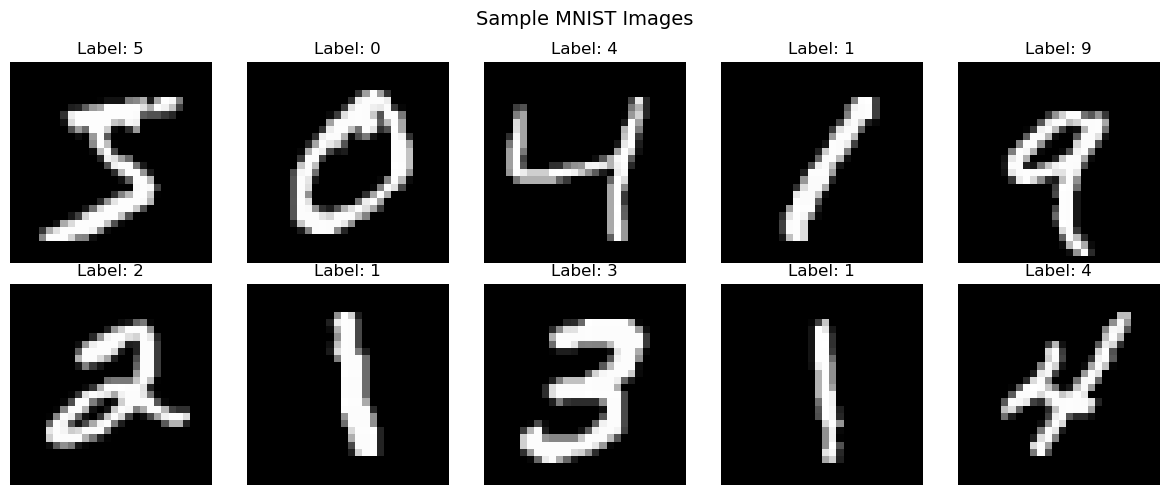


One image is a grid of 28×28 pixel values
Pixel values range from 0 (black) to 255 (white)


In [3]:
# Show the first 10 training images with their labels
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample MNIST Images', fontsize=14)

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')       
    ax.set_title(f'Label: {y_train[i]}')     
    ax.axis('off')                           

plt.tight_layout()
plt.show()

# Show the pixel values of just one image
print(f"\nOne image is a grid of {X_train[0].shape[0]}×{X_train[0].shape[1]} pixel values")
print(f"Pixel values range from {X_train[0].min()} (black) to {X_train[0].max()} (white)")

In [4]:
# Normalize: divide by 255 to get values between 0 and 1
X_train = X_train / 255.0
X_test  = X_test  / 255.0
print(f"After normalization — min: {X_train.min():.1f}, max: {X_train.max():.1f}")
print()

# Flatten: reshape (60000, 28, 28) → (60000, 784)
# Each 28×28 image becomes a single list of 784 numbers
X_train_flat = X_train.reshape(X_train.shape[0], -1)   # -1 means "figure out this dimension automatically"
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

print(f"Before flattening: {X_train.shape}")
print(f"After flattening : {X_train_flat.shape}")
print()
print("Data is ready to go into the neural network!")

After normalization — min: 0.0, max: 1.0

Before flattening: (60000, 28, 28)
After flattening : (60000, 784)

Data is ready to go into the neural network!


In [5]:
# Building a Sequential Neural Network
model = keras.Sequential([
    # Input layer: 784 inputs → 128 neurons with ReLU activation
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    # Dropout: randomly disables 20% of neurons to reduce overfitting
    keras.layers.Dropout(0.2),
    # Hidden layer: 64 neurons with ReLU activation
    keras.layers.Dense(64, activation='relu'),
    # Dropout layer
    keras.layers.Dropout(0.2),
    # Output layer: 10 neurons (digits 0–9) with Softmax probabilities
    keras.layers.Dense(10, activation='softmax')
])
# Display the model architecture
model.summary()

C:\Users\lenovo\Anaconda\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer='adam',                           # How the model learns
    loss='sparse_categorical_crossentropy',     # How we measure mistakes
    metrics=['accuracy']                        # What we track
)

print("Model compiled and ready to train!")

Model compiled and ready to train!


In [7]:
# Train the neural network and save training history
history = model.fit(
    X_train_flat,          # Training images
    y_train,               # Correct labels
    epochs=10,             # Train for 10 complete passes over the dataset
    batch_size=32,         # Process 32 images at a time
    validation_split=0.1,  # Reserve 10% of training data for validation
    verbose=1              # Display training progress
)

print("\n Training complete!")

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.8907 - loss: 0.3577 - val_accuracy: 0.9673 - val_loss: 0.1131
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9485 - loss: 0.1718 - val_accuracy: 0.9740 - val_loss: 0.0919
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9596 - loss: 0.1325 - val_accuracy: 0.9765 - val_loss: 0.0784
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9658 - loss: 0.1121 - val_accuracy: 0.9762 - val_loss: 0.0797
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.9699 - loss: 0.0984 - val_accuracy: 0.9783 - val_loss: 0.0737
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9736 - loss: 0.0852 - val_accuracy: 0.9803 - val_loss: 0.0700
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9751 - loss: 0.0786 - val_accuracy: 0.9800 - val_loss: 0.0713
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9771 - loss:

In [8]:
# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test_flat, y_test, verbose=0)

print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")
print()
print(f"This means the model correctly identified {test_accuracy * 100:.1f}% of the {len(y_test)} test images!")

Test Accuracy : 97.76%
Test Loss     : 0.0805

This means the model correctly identified 97.8% of the 10000 test images!
